# Notebook 04 — Severity Model
**Project: Coastal Property Catastrophe Loss Model**

Train an XGBoost regression model to predict **log(building claim amount)** given property and storm event features. This model provides the `PERSPVALUE` (expected loss given event) column in our generated ELTs.

## Approach
- **Target:** `log(amountPaidOnBuildingClaim)` — log-normal transformation
- **Training set:** Only records where a claim was actually paid (positive losses)
- **Validation:** 80/20 train-test split + 5-fold CV
- **Uncertainty:** Training RMSE on log scale → `STDDEVC`/`STDDEVI` in ELT
- **Explainability:** SHAP values reveal which features drive large losses

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from severity_model import SeverityModel

DATA_DIR = Path('../data/raw')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

X = pd.read_parquet(DATA_DIR / 'features.parquet')
targets = pd.read_parquet(DATA_DIR / 'targets.parquet')
y_sev = targets['log_severity']

print(f'Feature matrix: {X.shape}')
print(f'Severity records (non-NaN): {y_sev.notna().sum():,}')

Feature matrix: (336662, 20)
Severity records (non-NaN): 258,534


## 1. Train/Test Split

In [2]:
# Split before training (use all data for feature engineering, split for model eval)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_sev, test_size=0.2, random_state=42
)

print(f'Train set: {len(X_train):,} total | {y_train.notna().sum():,} with claims')
print(f'Test set:  {len(X_test):,} total | {y_test.notna().sum():,} with claims')

Train set: 269,329 total | 206,707 with claims
Test set:  67,333 total | 51,827 with claims


## 2. Train Severity Model

In [3]:
sev_model = SeverityModel(
    params={
        'n_estimators': 1500,
        'max_depth': 6,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 10,
        'early_stopping_rounds': 50,
    }
)

sev_model.fit(X_train, y_train, verbose=True)

[0]	validation_0-rmse:1.48314
[100]	validation_0-rmse:1.18491
[200]	validation_0-rmse:1.15987
[300]	validation_0-rmse:1.14576
[400]	validation_0-rmse:1.13628
[500]	validation_0-rmse:1.13015
[600]	validation_0-rmse:1.12597
[700]	validation_0-rmse:1.12281
[800]	validation_0-rmse:1.12000
[900]	validation_0-rmse:1.11752
[1000]	validation_0-rmse:1.11597
[1100]	validation_0-rmse:1.11449
[1200]	validation_0-rmse:1.11327
[1300]	validation_0-rmse:1.11218
[1400]	validation_0-rmse:1.11123
[1499]	validation_0-rmse:1.11059


## 3. Evaluate on Test Set

Test Set Performance:
  R² (log scale):       0.4489
  RMSE (log scale):     1.1085
  MAE (log scale):      0.8454
  RMSE ($):             $68,833
  MAE ($):              $27,011
  Test records:         51,827


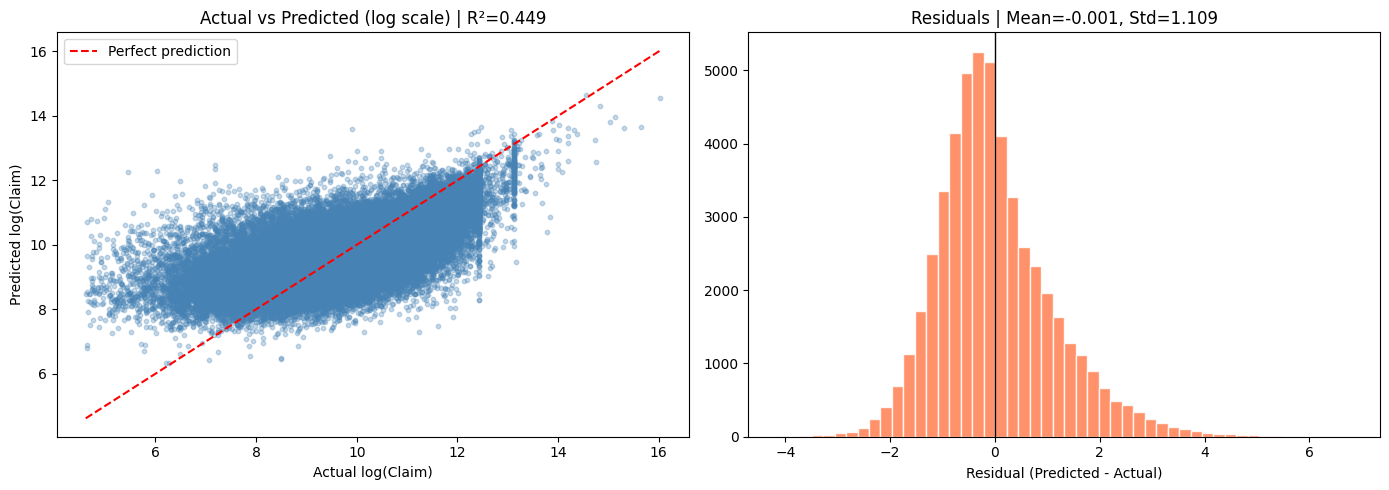

In [4]:
metrics = sev_model.evaluate(X_test, y_test)

print('Test Set Performance:')
print(f"  R² (log scale):       {metrics['r2']:.4f}")
print(f"  RMSE (log scale):     {metrics['rmse_log']:.4f}")
print(f"  MAE (log scale):      {metrics['mae_log']:.4f}")
print(f"  RMSE ($):             ${metrics['rmse_dollar']:,.0f}")
print(f"  MAE ($):              ${metrics['mae_dollar']:,.0f}")
print(f"  Test records:         {metrics['n_test']:,}")

# Actual vs predicted plot
valid = y_test.notna()
log_preds = sev_model.predict(X_test[valid], return_log=True)
log_true  = y_test[valid].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted (log scale)
axes[0].scatter(log_true, log_preds, alpha=0.3, s=10, color='steelblue')
lims = [min(log_true.min(), log_preds.min()), max(log_true.max(), log_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log(Claim)')
axes[0].set_ylabel('Predicted log(Claim)')
axes[0].set_title(f'Actual vs Predicted (log scale) | R²={metrics["r2"]:.3f}', fontsize=12)
axes[0].legend()

# Residuals
residuals = log_preds - log_true
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title(f'Residuals | Mean={residuals.mean():.3f}, Std={residuals.std():.3f}', fontsize=12)
axes[1].set_xlabel('Residual (Predicted - Actual)')

plt.tight_layout()
plt.savefig('../data/fig_04_severity_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Importance (SHAP)

Top 10 features by SHAP importance:
                feature  mean_abs_shap
       log_storm_damage       0.484904
              longitude       0.288169
  log_building_coverage       0.265189
coverage_to_value_ratio       0.233986
               latitude       0.230240
 construction_age_years       0.150589
           is_post_firm       0.102061
           has_basement       0.089053
             num_floors       0.053272
  log_contents_coverage       0.040473


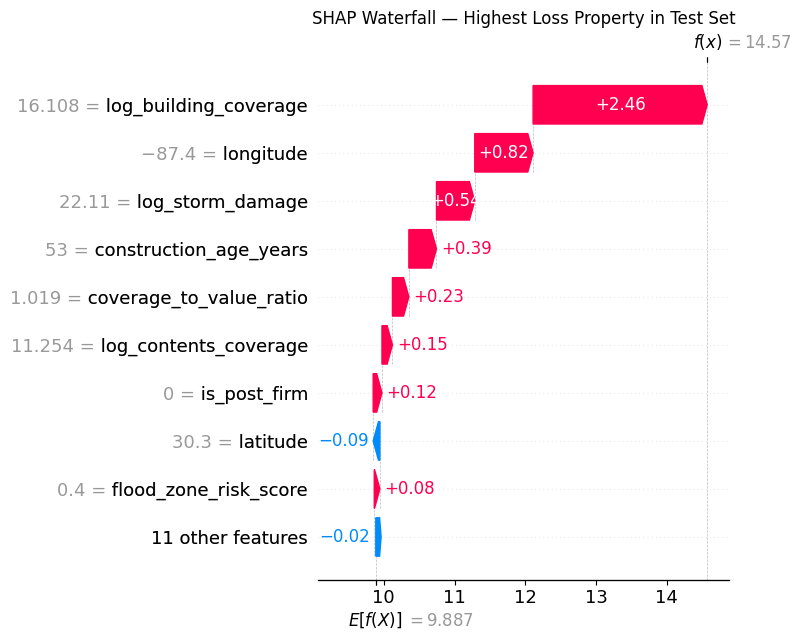

In [5]:
try:
    import shap

    # SHAP summary
    shap_summary = sev_model.shap_summary(X_test[valid], max_samples=500)
    print('Top 10 features by SHAP importance:')
    print(shap_summary.head(10).to_string(index=False))

    # SHAP waterfall plot for a high-loss example
    explainer = shap.TreeExplainer(sev_model._model)
    high_loss_idx = y_test[valid].nlargest(1).index[0]
    X_example = sev_model._align_features(X_test.loc[[high_loss_idx]])
    shap_vals = explainer(X_example)

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(shap_vals[0], max_display=10, show=False)
    plt.title('SHAP Waterfall — Highest Loss Property in Test Set', fontsize=12)
    plt.tight_layout()
    plt.savefig('../data/fig_04_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()

except ImportError:
    print('shap not installed. Run: pip install shap')
    # Fall back to XGBoost built-in importance
    print('\nXGBoost feature importances:')
    print(sev_model.feature_importances.head(10).to_string())

## 5. Cross-Validation

In [6]:
cv_results = sev_model.cross_validate(X, y_sev, n_folds=5, verbose=True)
print('\n5-Fold CV Results:')
print(cv_results.to_string(index=False))
print(f"\nMean R²:       {cv_results['r2'].mean():.4f} ± {cv_results['r2'].std():.4f}")
print(f"Mean RMSE(log): {cv_results['rmse_log'].mean():.4f} ± {cv_results['rmse_log'].std():.4f}")


5-Fold CV Results:
 fold  rmse_log  mae_log       r2
    1  1.101941 0.842069 0.455889
    2  1.105211 0.842471 0.455613
    3  1.103732 0.842184 0.455800
    4  1.098577 0.836934 0.462526
    5  1.096838 0.838464 0.452491

Mean R²:       0.4565 ± 0.0037
Mean RMSE(log): 1.1013 ± 0.0035


## 6. Save Model

In [7]:
model_path = MODEL_DIR / 'severity_model.joblib'
sev_model.save(str(model_path))
print(f'Severity model saved to {model_path}')
print(f'Training log RMSE (used as sigma for ELT): {sev_model.train_log_rmse:.4f}')
print('\n✅ Notebook 04 complete — proceed to 05_frequency_model.ipynb')

Severity model saved to ..\models\severity_model.joblib
Training log RMSE (used as sigma for ELT): 1.0307

✅ Notebook 04 complete — proceed to 05_frequency_model.ipynb
